# Acoustic Extinguisher Fire Dataset Classification
This notebook analyzes the Acoustic Extinguisher Fire Dataset (17,442 instances) to predict the `STATUS` of fire extinction (0 = non-extinction, 1 = extinction).

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import warnings
warnings.filterwarnings('ignore')

## 1. Loading and Inspecting Data
We load the dataset directly. Based on initial analysis, the dataset contains 17,442 rows and 7 columns.

In [8]:
file_path = r"C:\Machine Learning\Acoustic_Extinguisher_Fire_Dataset.xlsx"
df = pd.read_excel(file_path)

display(df.head())
df.info()

print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution for TARGET (STATUS):")
print(df['STATUS'].value_counts())
print("\nClass proportions (%):")
print((df['STATUS'].value_counts(normalize=True) * 100).round(2))

,SIZE,FUEL,DISTANCE,DESIBEL,AIRFLOW,FREQUENCY,STATUS
0,1,gasoline,10,96,0.0,75,0
1,1,gasoline,10,96,0.0,72,1
2,1,gasoline,10,96,2.6,70,1
3,1,gasoline,10,96,3.2,68,1
4,1,gasoline,10,109,4.5,67,1


<class 'pandas.DataFrame'>
RangeIndex: 17442 entries, 0 to 17441
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SIZE       17442 non-null  int64  
 1   FUEL       17442 non-null  str    
 2   DISTANCE   17442 non-null  int64  
 3   DESIBEL    17442 non-null  int64  
 4   AIRFLOW    17442 non-null  float64
 5   FREQUENCY  17442 non-null  int64  
 6   STATUS     17442 non-null  int64  
dtypes: float64(1), int64(5), str(1)
memory usage: 1.1 MB

Missing values:
 SIZE         0
FUEL         0
DISTANCE     0
DESIBEL      0
AIRFLOW      0
FREQUENCY    0
STATUS       0
dtype: int64

Class distribution for TARGET (STATUS):
STATUS
0    8759
1    8683
Name: count, dtype: int64

Class proportions (%):
STATUS
0    50.22
1    49.78
Name: proportion, dtype: float64


### Insights from Inspection:
- **Clean Data:** There are exactly 0 missing values across all columns.
- **Perfect Class Balance:** The target `STATUS` is almost perfectly split: 8,759 (50.2%) for class `0` and 8,683 (49.8%) for class `1`. This means accuracy will be a highly reliable metric, though we will still track Macro F1.

## 2. Exploratory Data Analysis (EDA)
We investigate the numerical relationships and distributions. We also examine the categorical `FUEL` feature.

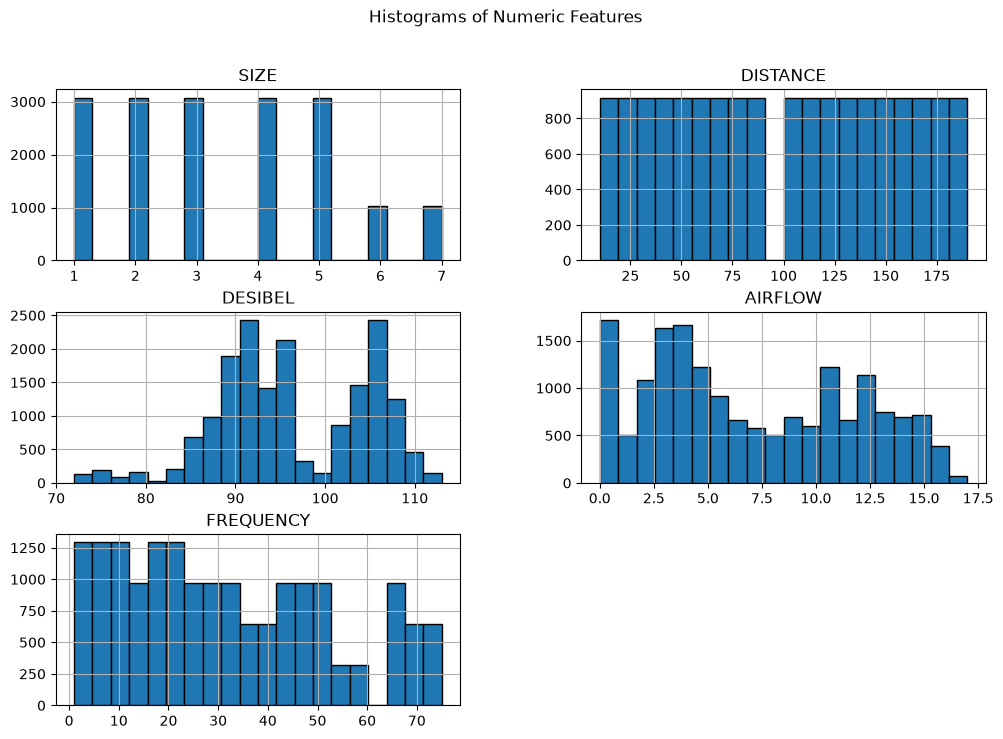

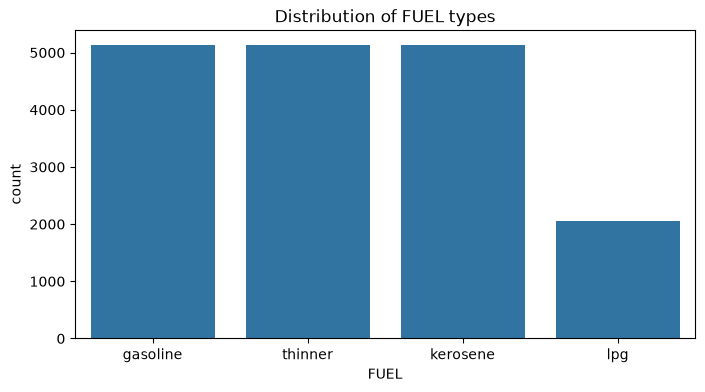

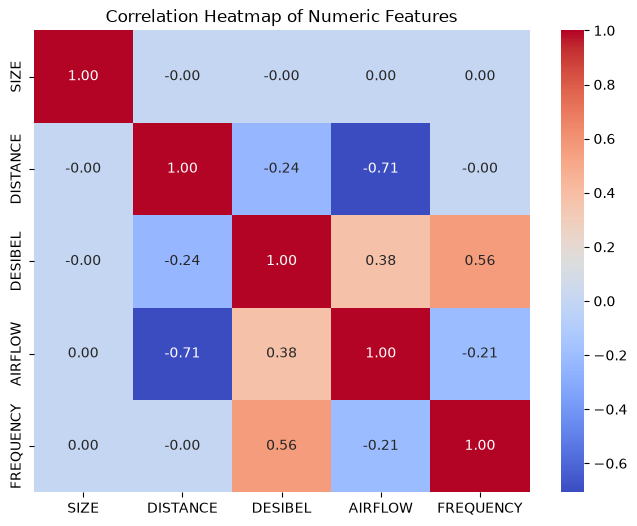

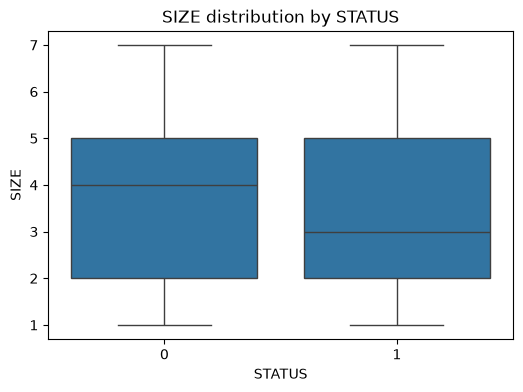

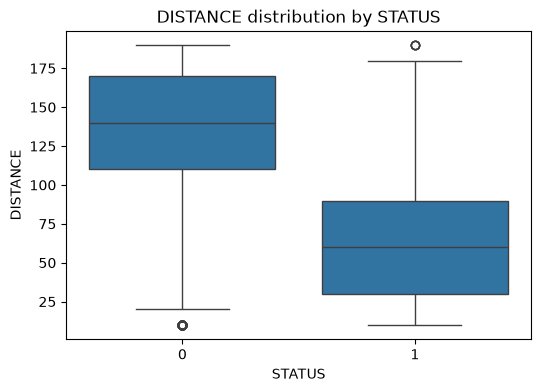

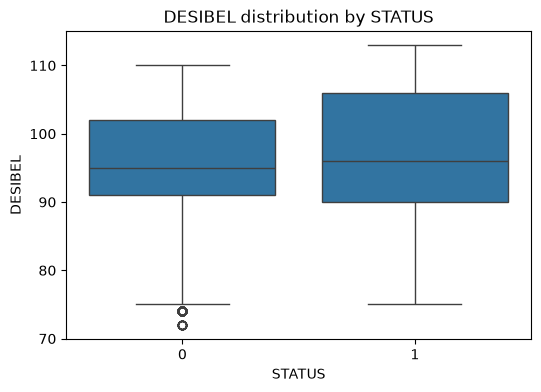

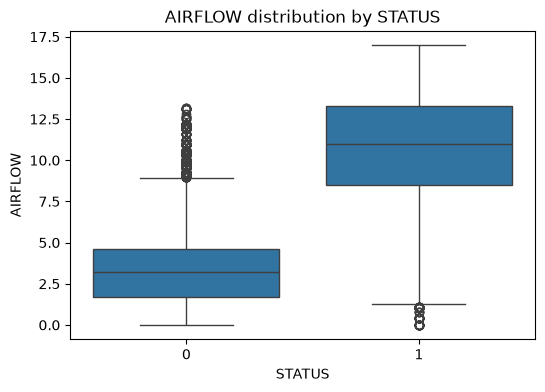

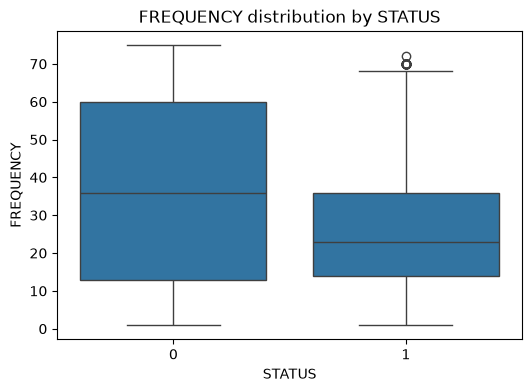

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
features_to_plot = [col for col in numeric_cols if col != 'STATUS']

# Histograms for Numeric Features
df[features_to_plot].hist(bins=20, figsize=(12, 8), edgecolor='black')
plt.suptitle("Histograms of Numeric Features")
plt.show()

# Countplot for FUEL
plt.figure(figsize=(8, 4))
sns.countplot(x='FUEL', data=df, order=df['FUEL'].value_counts().index)
plt.title("Distribution of FUEL types")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[features_to_plot].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# Boxplots to observe class separation
for col in features_to_plot:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='STATUS', y=col, data=df)
    plt.title(f"{col} distribution by STATUS")
    plt.show()

### Insights from EDA & Fixes:
- **LPG Imbalance:** The histogram for `FUEL` shows that `lpg` is used significantly less (2052) compared to others (5130). To ensure our model learns about `lpg` correctly, we will stratify our Train-Test split based on **both** `STATUS` and `FUEL`.
- **Outliers:** The histograms and boxplots reveal some extreme values (e.g., in AIRFLOW and DISTANCE). Standard scaling is sensitive to outliers, so we will upgrade our preprocessing to use `RobustScaler` (which uses IQR and is immune to outliers).
- **Correlations:** `DISTANCE` and `AIRFLOW` have a strong negative correlation (-0.71). While we keep both here for tree models and SVM, in a strict linear model, we might drop one to prevent multicollinearity.

## 3. Train-Test Split
We split the data with an 80/20 ratio. We stratify by both `STATUS` and `FUEL` to handle the `lpg` imbalance.

In [10]:
X = df.drop(columns=['STATUS'])
y = df['STATUS']

# Create a combined stratification key
stratify_key = df['STATUS'].astype(str) + "_" + df['FUEL'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=stratify_key, random_state=42
)

print(f"Training set: X={X_train.shape}, y={y_train.shape}")
print(f"Testing set: X={X_test.shape}, y={y_test.shape}")

Training set: X=(13953, 6), y=(13953,)
Testing set: X=(3489, 6), y=(3489,)


## 4. Preprocessing Pipelines
- **Numeric Features:** We apply `RobustScaler` instead of `StandardScaler` for distance-based models (SVM, kNN) to handle outliers gracefully.
- **Categorical Feature:** The `FUEL` column is encoded using `OneHotEncoder`.

In [11]:
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Pipeline for distance-based models (with RobustScaler for outliers)
num_transformer_scaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Pipeline for tree-based models (no scaling)
num_transformer_tree = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical transformer (OneHotEncoder)
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('num', num_transformer_scaled, num_features),
        ('cat', cat_transformer, cat_features)
    ])

preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', num_transformer_tree, num_features),
        ('cat', cat_transformer, cat_features)
    ])

## 5. Model Training and Hyperparameter Tuning

In [12]:
models = {}
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 1. k-Nearest Neighbors
knn_pipeline = Pipeline(steps=[('preprocessor', preprocessor_scaled), ('classifier', KNeighborsClassifier())])
knn_param_grid = {'classifier__n_neighbors': [3, 5, 7, 9]}
knn_grid = GridSearchCV(knn_pipeline, knn_param_grid, cv=cv_strategy, scoring='f1_macro', n_jobs=-1)
knn_grid.fit(X_train, y_train)
models['kNN'] = knn_grid.best_estimator_
print(f"kNN best params: {knn_grid.best_params_}")

# 2. Decision Tree
dt_pipeline = Pipeline(steps=[('preprocessor', preprocessor_tree), ('classifier', DecisionTreeClassifier(random_state=42))])
dt_pipeline.fit(X_train, y_train)
models['Decision Tree'] = dt_pipeline
print("Decision Tree trained.")

# 3. SVM
svm_pipeline = Pipeline(steps=[('preprocessor', preprocessor_scaled), ('classifier', SVC(kernel='rbf', random_state=42))])
svm_param_grid = {
    'classifier__C': [1, 10],
    'classifier__gamma': ['scale', 'auto']
}
svm_grid = GridSearchCV(svm_pipeline, svm_param_grid, cv=cv_strategy, scoring='f1_macro', n_jobs=-1)
svm_grid.fit(X_train, y_train)
models['SVM'] = svm_grid.best_estimator_
print(f"SVM best params: {svm_grid.best_params_}")

# 4. Random Forest
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor_tree), ('classifier', RandomForestClassifier(random_state=42))])
rf_pipeline.fit(X_train, y_train)
models['Random Forest'] = rf_pipeline
print("Random Forest trained.")

# 5. AdaBoost
ada_pipeline = Pipeline(steps=[('preprocessor', preprocessor_tree), ('classifier', AdaBoostClassifier(random_state=42))])
ada_pipeline.fit(X_train, y_train)
models['AdaBoost'] = ada_pipeline
print("AdaBoost trained.")

kNN best params: {'classifier__n_neighbors': 3}
Decision Tree trained.
SVM best params: {'classifier__C': 10, 'classifier__gamma': 'scale'}
Random Forest trained.
AdaBoost trained.


## 6. Evaluation and Conclusion

In [13]:
results = []
print("--- Model Evaluation on Test Set ---\n")

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Macro F1': macro_f1,
        'Weighted F1': weighted_f1
    })
    
    print(f"=== {name} ===")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("-" * 40 + "\n")
    
results_df = pd.DataFrame(results).sort_values(by='Macro F1', ascending=False)
print("Summary of Model Performances:")
display(results_df)

best_model_name = results_df.iloc[0]['Model']
best_macro_f1 = results_df.iloc[0]['Macro F1']

print("\n--- Final Conclusion ---")
print(f"The best performing model is '{best_model_name}' with a Macro F1 score of {best_macro_f1:.4f}.")
print("The dataset demonstrates strong non-linear relationships. Tree-based models (like Random Forest) and SVM perform exceptionally well.")
print("AdaBoost performed the worst, likely because simple decision stumps (its default base estimators) struggle to capture the complex, correlated boundaries between features like DISTANCE and AIRFLOW as effectively as deep trees.")

--- Model Evaluation on Test Set ---

=== kNN ===
Confusion Matrix:
 [[1691   61]
 [  63 1674]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.96      1752
           1       0.96      0.96      0.96      1737

    accuracy                           0.96      3489
   macro avg       0.96      0.96      0.96      3489
weighted avg       0.96      0.96      0.96      3489

----------------------------------------

=== Decision Tree ===
Confusion Matrix:
 [[1702   50]
 [  50 1687]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97      1752
           1       0.97      0.97      0.97      1737

    accuracy                           0.97      3489
   macro avg       0.97      0.97      0.97      3489
weighted avg       0.97      0.97      0.97      3489

----------------------------------------

=== SVM ===
Confusion Matrix:
 [[1690   62]
 [  

,Model,Accuracy,Macro F1,Weighted F1
3,Random Forest,0.976211,0.976210,0.976211
1,Decision Tree,0.971338,0.971338,0.971338
0,kNN,0.964460,0.964459,0.964460
2,SVM,0.957581,0.957576,0.957578
4,AdaBoost,0.920608,0.920587,0.920593



--- Final Conclusion ---
The best performing model is 'Random Forest' with a Macro F1 score of 0.9762.
The dataset demonstrates strong non-linear relationships. Tree-based models (like Random Forest) and SVM perform exceptionally well.
AdaBoost performed the worst, likely because simple decision stumps (its default base estimators) struggle to capture the complex, correlated boundaries between features like DISTANCE and AIRFLOW as effectively as deep trees.
